# Module 1 — Regression on HPC

**DesignSafe AI Training**

[![Try on DesignSafe](https://raw.githubusercontent.com/DesignSafe-CI/training-ai/main/DesignSafe-Badge.svg)](https://jupyter.designsafe-ci.org/hub/user-redirect/lab/tree/CommunityData/Training/2026-SPARC/Day3/3b-SciML/01-opensees-ml-regression.ipynb)

---

## Sweeping M, L and E to learn the period equation

Run one cantilever 75 times, changing three things each time — the tip mass $M$, the
column length $L$, and the modulus $E$ — and record the fundamental period $T$ from
the OpenSees eigen solve. Then fit a regression that predicts $T$ from
$(M, L, E)$.

The point is that we already know the answer, so the regression is checkable.

<img src="figs/period-power-law.png" width="100%"/>

### A cantilever's period follows a power law

A cantilever with a lumped tip mass has lateral stiffness $k = 3EI/L^3$, so its
period is

$$T \;=\; 2\pi\sqrt{\frac{M}{k}} \;=\; 2\pi\sqrt{\frac{M L^{3}}{3EI}}$$

That is a **power law** — panel B above — and no straight line fits it.

### Taking logarithms makes it linear

$T$ is a product of powers, so taking logarithms turns the products into sums and
the exponents into slopes:

$$\boxed{\;\log T \;=\; c \;+\; \tfrac{1}{2}\log M \;+\; \tfrac{3}{2}\log L \;-\; \tfrac{1}{2}\log E\;}$$

$$\text{where}\quad c = \log\!\left(\frac{2\pi}{\sqrt{3I}}\right)$$

In log space the data falls on straight, parallel lines — panel C — which is exactly
what ordinary least squares is built to fit.

So if we regress $\log T$ on $\log M$, $\log L$, and $\log E$, the three fitted
coefficients **should come out as $+0.5$, $+1.5$, and $-0.5$**. They are not
abstract weights; they are the physical exponents of the period equation, and the
model has to discover them from 75 simulations.

### Exact physics turns the fit into a test of the whole workflow

Because the physics is exact, the fit is a **test of the whole workflow**. Anything
other than $[0.5,\ 1.5,\ -0.5]$ with $R^2 = 1$ means the plumbing broke somewhere —
the sweep, the staging, a task's output, the aggregation. The recovered exponents
check the pipeline end to end.

And the catch that sets up Module 2: this only worked because **we knew to take the
logarithms.** Swap in a model with no closed form and no fixed feature basis is
available.

## 75 runs, three log features, one log target

| | |
|---|---|
| **Data** | 75 OpenSeesPy pushover runs, one per grid point of `NodalMass × LCol × E` |
| **Features** | $\log M$, $\log L$, $\log E$ |
| **Target** | $\log T$, the fundamental period from the OpenSees eigen solve |
| **Model** | Ordinary least squares (scikit-learn `LinearRegression`, `numpy.linalg.lstsq` fallback) |
| **Split** | 80/20 train/test (60/15 runs, fixed seed) |
| **Expected** | `coef ≈ [c, 0.5, 1.5, −0.5]`, $R^2 = 1.0$ |

## PyLauncher sweeps; a post-script fits the regression

1. Sweep `NodalMass × LCol × E` over a 2D cantilever pushover in OpenSeesPy.
2. Each combination runs as an independent PyLauncher task.
3. When all tasks finish, `ml_post.sh` (the required post-script) aggregates
   `out_*/metrics.json`, fits the regression on $\log T$, and renders a diagnostic
   PDF/PNG.
4. The archive holds the fitted model JSON, a per-task predictions CSV, a short
   report, and `opensees_ml_diagnostics.png`.

The ML layer is a standard supervised pipeline: feature matrix → train/test split →
linear fit → JSON model artifact → diagnostic figure. It trains on data the sweep
generates, so it needs no external dataset.

This folder already contains the supporting files; the notebook does not rewrite
them.

- `cantilever.py` — one OpenSeesPy pushover task
- `aggregate_and_train.py` — aggregation + regression
- `postprocess.py` — diagnostic plots (PDF/PNG)
- `ml_post.sh` — the required post-script; runs the aggregator and plotter
- `requirements.txt` — extra packages for the job's temp environment
- `setup.sh` — pre-script staging the TACC-compiled OpenSeesPy

Run this notebook **from the folder that contains those files** (e.g. copy the whole
folder into your `~/MyData/`).

In [ ]:
%pip install dapi --quiet

In [1]:
import os
from pathlib import Path
from dapi import DSClient

ds = DSClient()
input_dir = Path(os.getcwd())
print(f"Input directory: {input_dir}")
for fn in (
    "cantilever.py",
    "aggregate_and_train.py",
    "postprocess.py",
    "setup.sh",
    "ml_post.sh",
    "requirements.txt",
):
    assert (input_dir / fn).exists(), f"Missing: {fn}"
print("All required files present.")

/Users/krishna/.claude/jobs/791f8e64/tmp/mlrun/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Authentication successful.


TMS credentials ready: frontera, stampede3, ls6


Input directory: /Users/krishna/.claude/jobs/791f8e64/tmp/mlrun/opensees_ml
All required files present.


## Define the parameter sweep

The three parameter lists combine into 5 × 5 × 3 = **75 tasks**. Increase the lists for a bigger training set.

In [ ]:
sweep = {
    "NODAL_MASS": [4.19, 4.39, 4.59, 4.79, 4.99],  # kip*s^2/in
    "LCOL": [100, 200, 300, 400, 500],  # in
    "EMOD": [
        3600,
        4227,
        5000,
    ],  # ksi
}

command = (
    "python3 cantilever.py --NodalMass NODAL_MASS --LCol LCOL --E EMOD "
    "--outDir out_NODAL_MASS_LCOL_EMOD"
)

## Preview the sweep grid

In [3]:
preview = ds.jobs.parametric_sweep.generate(command, sweep, preview=True)
print(f"Total runs: {len(preview)}")
preview.head()

Total runs: 75


,NODAL_MASS,LCOL,EMOD
0,4.19,100,3600
1,4.19,100,4227
2,4.19,100,5000
3,4.19,200,3600
4,4.19,200,4227


## Write `runsList.txt` and `call_pylauncher.py`

In [4]:
commands = ds.jobs.parametric_sweep.generate(command, sweep, str(input_dir))
print(f"Generated {len(commands)} task commands\n")
print("=== runsList.txt (first 5 lines) ===")
print("\n".join((input_dir / "runsList.txt").read_text().splitlines()[:5]))
print("...")

Generated 75 task commands

=== runsList.txt (first 5 lines) ===
python3 cantilever.py --NodalMass 4.19 --LCol 100 --E 3600 --outDir out_4.19_100_3600
python3 cantilever.py --NodalMass 4.19 --LCol 100 --E 4227 --outDir out_4.19_100_4227
python3 cantilever.py --NodalMass 4.19 --LCol 100 --E 5000 --outDir out_4.19_100_5000
python3 cantilever.py --NodalMass 4.19 --LCol 200 --E 3600 --outDir out_4.19_200_3600
python3 cantilever.py --NodalMass 4.19 --LCol 200 --E 4227 --outDir out_4.19_200_4227
...


## Bundle the inputs into one ZIP

Tapis stages each file of a directory input as its own transfer task (~40 s per file when the tenant transfer queue is busy), so eight loose files can spend minutes staging. Bundling them into a single `inputs.zip`, submitted from a directory containing only the bundle, turns eight transfers into one. The app expands it before anything else runs (`UNZIP_INPUTS`), so the pre-script, requirements file, and task scripts can all live inside the bundle.

In [5]:
import zipfile

staged_dir = input_dir / "staged"
staged_dir.mkdir(exist_ok=True)
bundle = staged_dir / "inputs.zip"

payload = [
    "cantilever.py",
    "aggregate_and_train.py",
    "postprocess.py",
    "setup.sh",
    "ml_post.sh",
    "requirements.txt",
    "runsList.txt",
    "call_pylauncher.py",
]
with zipfile.ZipFile(bundle, "w", zipfile.ZIP_DEFLATED) as zf:
    for fn in payload:
        zf.write(input_dir / fn, arcname=fn)
print(f"Bundled {len(payload)} files into {bundle} ({bundle.stat().st_size:,} bytes)")

Bundled 8 files into /Users/krishna/.claude/jobs/791f8e64/tmp/mlrun/opensees_ml/staged/inputs.zip (6,799 bytes)


## Submit the job

Set your TACC allocation, then run.

In [ ]:
allocation = "DS-Portal-SPARC2026"  # <-- replace with your allocation

job = ds.jobs.parametric_sweep.submit(
    str(staged_dir),  # contains only inputs.zip — one staged transfer
    app_id="python-s3",
    allocation=allocation,
    node_count=1,
    cores_per_node=48,
    max_minutes=30,
    queue="skx-dev",
    extra_env_vars=[
        {"key": "UNZIP_INPUTS", "value": "inputs"},
        {"key": "EXTRA_MODULES", "value": "opensees,hdf5/1.14.4"},
        {"key": "PRE_SCRIPT", "value": "setup.sh"},
        {"key": "PIP_REQUIREMENTS", "value": "requirements.txt"},
        {"key": "POST_SCRIPT", "value": "ml_post.sh"},
        {"key": "POST_SCRIPT_REQUIRED", "value": "True"},
    ],
)
print(f"Job UUID: {job.uuid}")
job.monitor(interval=30, timeout_minutes=90)

## Read the fitted model out of the job archive

The fit should return the exponents of the period
equation:

$$\log T = c + \underbrace{0.5}_{\log M} + \underbrace{1.5}_{\log L} \underbrace{-\,0.5}_{\log E}$$

and $R^2 = 1$ on the held-out runs, because the physics is exact and the only
question is whether the pipeline delivered the data intact.

In [7]:
import json

archive_uri = job.archive_uri
print(f"Archive: {archive_uri}")
for item in ds.files.list(f"{archive_uri}/inputDirectory/ml_results"):
    print(f"  {item.name}")

job.download_output(
    "inputDirectory/ml_results/opensees_ml_model.json",
    "opensees_ml_model.json",
)
with open("opensees_ml_model.json") as f:
    model = json.load(f)
print(json.dumps(model, indent=2))

Archive: tapis://designsafe.storage.default/kks32/tapis-jobs-archive/2026-08-09Z/f370f8ba-d5dd-4e29-8e9d-ab492cc623da-007


  opensees_ml_diagnostics.pdf
  opensees_ml_diagnostics.png
  opensees_ml_model.json
  opensees_ml_preds.csv
  opensees_ml_report.txt
{
  "type": "linear_regression",
  "fitter": "sklearn",
  "target": "period",
  "target_space": "log",
  "feature_names": [
    "bias",
    "log_NodalMass",
    "log_LCol",
    "log_E"
  ],
  "coef": [
    -5.657664877475027,
    0.500000000000017,
    1.5000000000000022,
    -0.49999999999999106
  ],
  "r2_train": 1.0,
  "r2_test": 1.0,
  "n_train": 60,
  "n_test": 15,
  "seed": 12345
}


### The fit recovers the coefficients

From the verified Stampede3 run above (75 tasks, one SKX node, 42 s):

| Coefficient | Recovered | Exact | Meaning |
| --- | --- | --- | --- |
| `bias` | −5.657665 | $\log\!\left(2\pi/\sqrt{3I}\right)$ | absorbs $2\pi$ and the fixed $I$ |
| `log_NodalMass` | **+0.500000** | $+\tfrac{1}{2}$ | $T \propto \sqrt{M}$ — heavier is slower |
| `log_LCol` | **+1.500000** | $+\tfrac{3}{2}$ | $T \propto L^{3/2}$ — the dominant term |
| `log_E` | **−0.500000** | $-\tfrac{1}{2}$ | $T \propto 1/\sqrt{E}$ — stiffer is faster |

$R^2 = 1.0000$ on both the 60 training and the 15 held-out test runs, with residuals
at machine epsilon ($\max|r| \approx 8 \times 10^{-15}$).

The regression was never told the period equation. It saw
75 rows of `(M, L, E, T)` from independent OpenSees jobs and recovered
$T = 2\pi\sqrt{ML^3/3EI}$ to fifteen significant figures — which simultaneously
confirms that the sweep, the staging, all 75 task outputs, and the aggregation are
correct. A single broken task would have shown up here.

Three coefficients, each one a physical exponent you can check by hand. Keep that
standard in mind for Module 2, where the same data goes into a neural network and
comes back as a few thousand weights that mean nothing on their own.

## Diagnostic plots confirm residuals at machine epsilon

`postprocess.py` runs on the compute node as part of `ml_post.sh` (the required post-script) and produces a 2×4 figure: feature histograms, target distribution, predicted-vs-truth scatter, residual panel, residual-vs-predicted, and a coefficient bar chart with the physics-expected exponents overlaid as red reference lines.

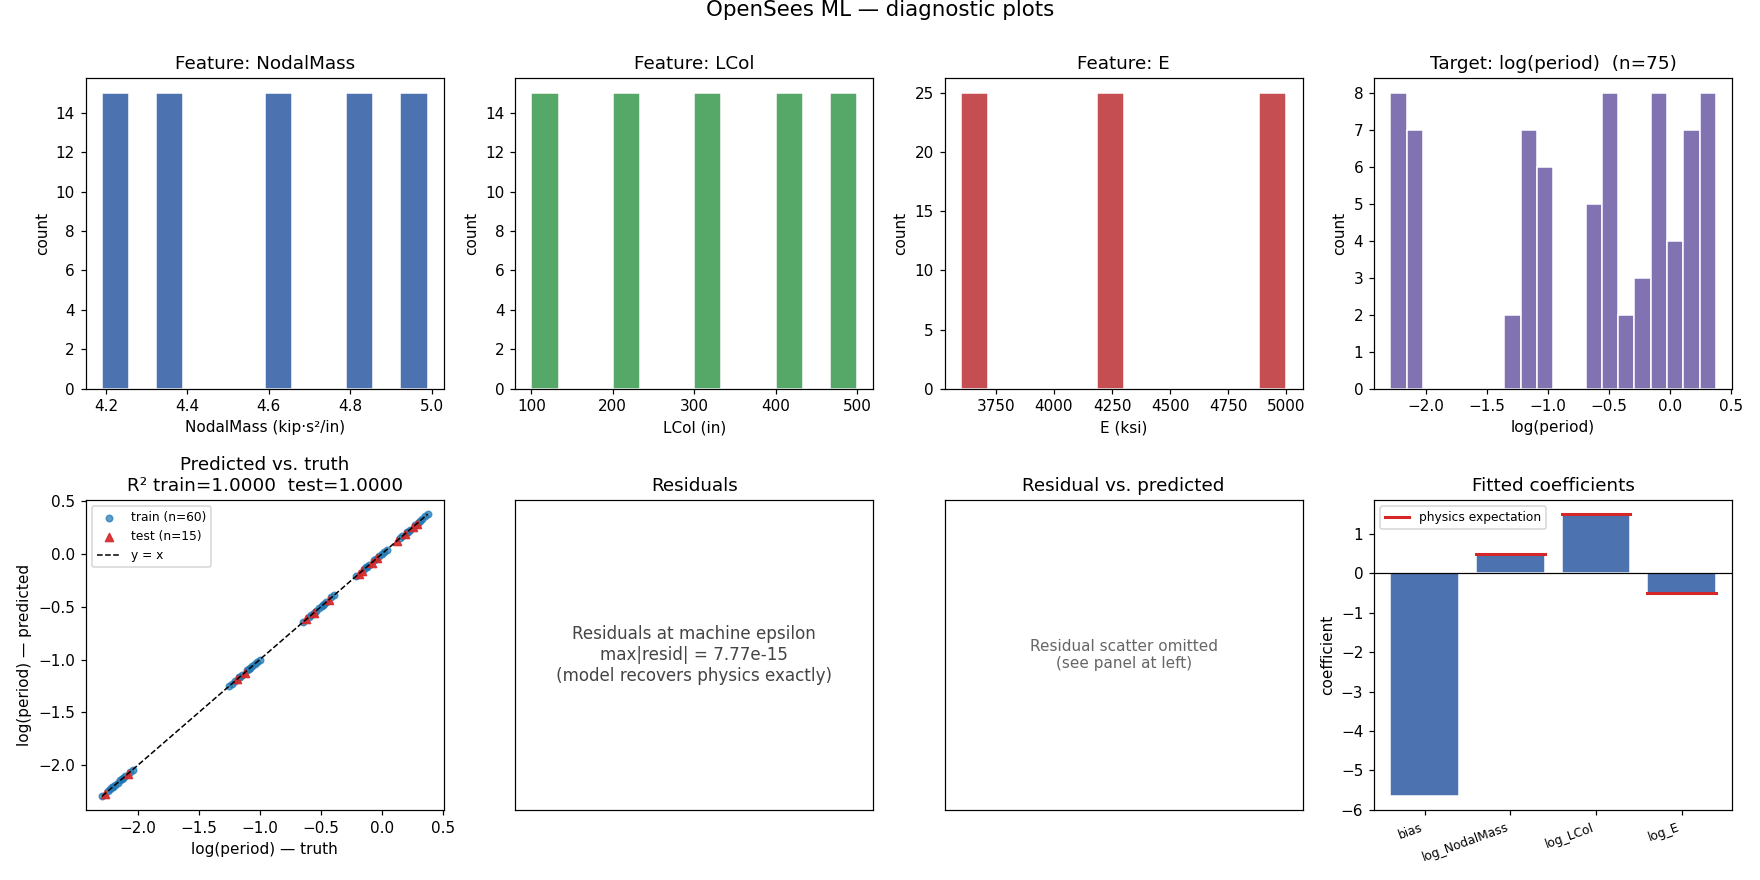

In [8]:
from IPython.display import Image, display

job.download_output(
    "inputDirectory/ml_results/opensees_ml_diagnostics.png",
    "opensees_ml_diagnostics.png",
)
display(Image("opensees_ml_diagnostics.png"))

Also download the PDF version (vector) and the per-task predictions CSV if you want to re-plot or do further analysis.

In [9]:
job.download_output(
    "inputDirectory/ml_results/opensees_ml_diagnostics.pdf",
    "opensees_ml_diagnostics.pdf",
)
job.download_output(
    "inputDirectory/ml_results/opensees_ml_preds.csv",
    "opensees_ml_preds.csv",
)
print("Downloaded diagnostics.pdf and preds.csv.")

Downloaded diagnostics.pdf and preds.csv.


## Re-plot the predictions locally from the CSV

`ml_post.sh` already rendered diagnostics on the compute node. The per-task predictions CSV supports custom analysis locally, so the cells below recreate two figures in the notebook. The first plots predicted versus truth colored by train/test split; the second sets the learned coefficients beside the physics expectation.

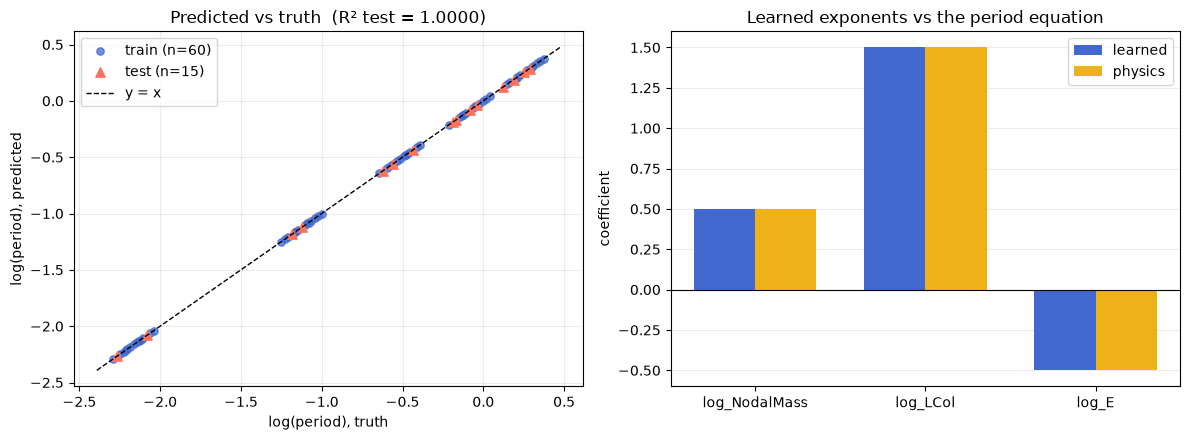

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

preds = pd.read_csv("opensees_ml_preds.csv")
train = preds[preds.split == "train"]
test = preds[preds.split == "test"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.scatter(
    train.log_target,
    train.log_pred,
    s=28,
    color="#4269d0",
    alpha=0.75,
    label=f"train (n={len(train)})",
)
ax.scatter(
    test.log_target,
    test.log_pred,
    s=45,
    color="#ff725c",
    marker="^",
    label=f"test (n={len(test)})",
)
lims = [preds.log_target.min() - 0.1, preds.log_target.max() + 0.1]
ax.plot(lims, lims, "k--", lw=1, label="y = x")
ax.set_xlabel("log(period), truth")
ax.set_ylabel("log(period), predicted")
ax.set_title(f"Predicted vs truth  (R² test = {model['r2_test']:.4f})")
ax.legend()
ax.grid(alpha=0.25)
ax.set_axisbelow(True)

ax = axes[1]
names = model["feature_names"][1:]
learned = model["coef"][1:]
expected = [0.5, 1.5, -0.5]
x = np.arange(len(names))
ax.bar(x - 0.18, learned, 0.36, color="#4269d0", label="learned")
ax.bar(x + 0.18, expected, 0.36, color="#efb118", label="physics")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("coefficient")
ax.set_title("Learned exponents vs the period equation")
ax.legend()
ax.grid(alpha=0.25, axis="y")
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()